# 4 - PCA and K-Means

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import adjusted_rand_score

In [2]:
# 4(a) Split into features and label, then standardize features with z-score
DATA_PATH = 'data/mobile_price.csv'
TARGET_COL = 'price_range'
RANDOM_STATE = 42

df = pd.read_csv(DATA_PATH)
X = df.drop(columns=[TARGET_COL]).values
y = df[TARGET_COL].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Original feature shape:', X.shape)
print('Standardized feature shape:', X_scaled.shape)
print('Label shape:', y.shape)

Original feature shape: (2000, 20)
Standardized feature shape: (2000, 20)
Label shape: (2000,)


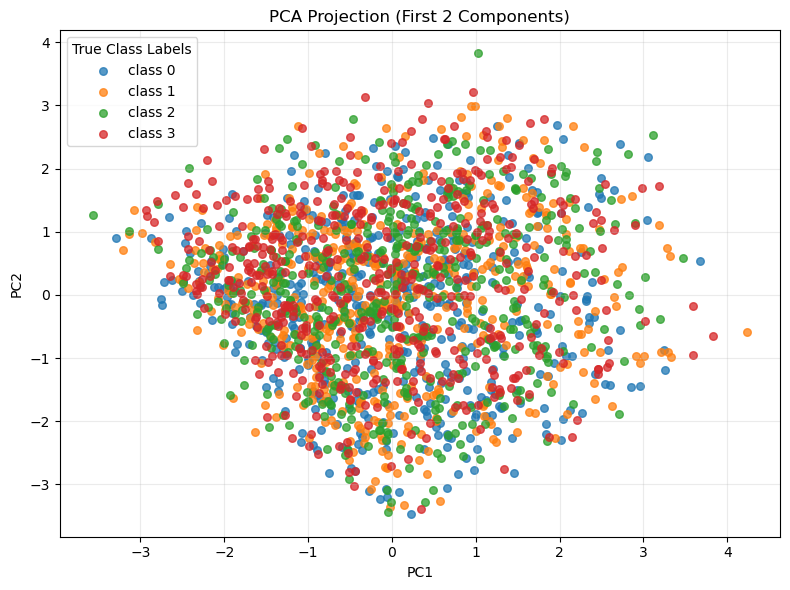

Explained variance ratio: [0.08386288 0.08112475]
Total explained variance (2 PCs): 0.16498762894281932


In [3]:
# 4(b) PCA to 2D and scatter plot with class-label legend
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
for label in np.unique(y):
    mask = y == label
    plt.scatter(
        X_pca_2d[mask, 0],
        X_pca_2d[mask, 1],
        s=30,
        alpha=0.75,
        label=f'class {label}'
    )

plt.title('PCA Projection (First 2 Components)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='True Class Labels')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print('Explained variance ratio:', pca.explained_variance_ratio_)
print('Total explained variance (2 PCs):', pca.explained_variance_ratio_.sum())

d:\Workspace\Applications\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "d:\Workspace\Applications\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "d:\Workspace\Applications\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Workspace\Applications\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fd

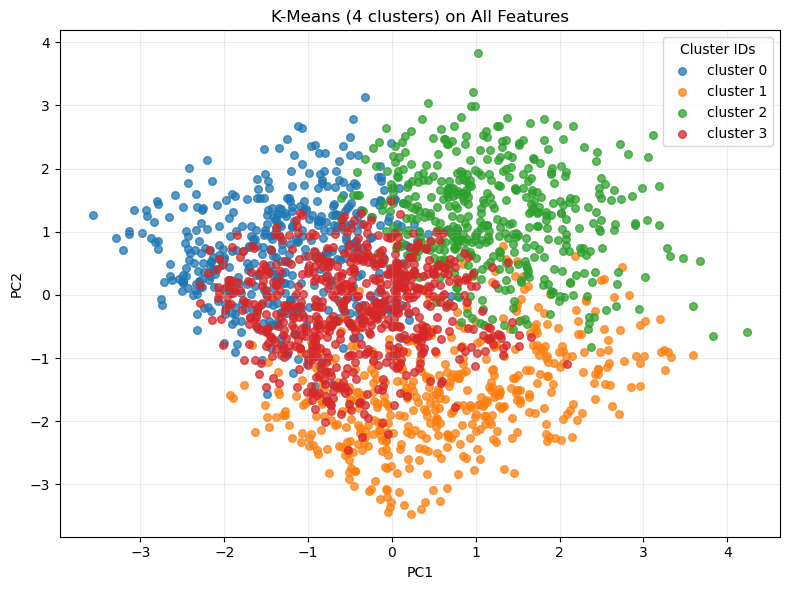

4(c) Adjusted Rand Index (all features): 0.005961567406388764


In [4]:
# 4(c) K-means on all standardized features (4 clusters)
kmeans_all = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
clusters_all = kmeans_all.fit_predict(X_scaled)
ari_all = adjusted_rand_score(y, clusters_all)

# Visualize clustering in 2D using PCA projection for display
plt.figure(figsize=(8, 6))
for cluster_id in np.unique(clusters_all):
    mask = clusters_all == cluster_id
    plt.scatter(
        X_pca_2d[mask, 0],
        X_pca_2d[mask, 1],
        s=30,
        alpha=0.75,
        label=f'cluster {cluster_id}'
    )

plt.title('K-Means (4 clusters) on All Features')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster IDs')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print('4(c) Adjusted Rand Index (all features):', ari_all)

d:\Workspace\Applications\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


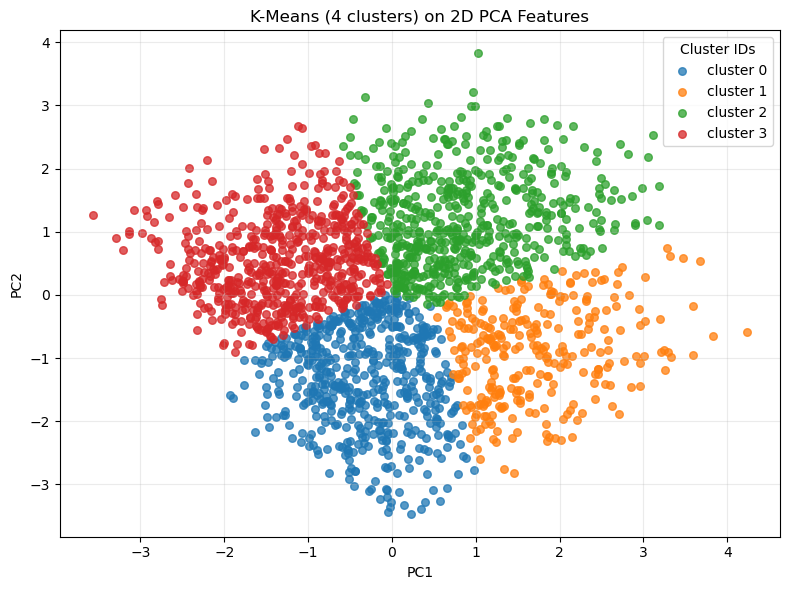

4(d) Adjusted Rand Index (2D PCA features): 0.001694571795386637


In [5]:
# 4(d) K-means on 2D PCA features (4 clusters)
kmeans_pca = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
clusters_pca = kmeans_pca.fit_predict(X_pca_2d)
ari_pca = adjusted_rand_score(y, clusters_pca)

plt.figure(figsize=(8, 6))
for cluster_id in np.unique(clusters_pca):
    mask = clusters_pca == cluster_id
    plt.scatter(
        X_pca_2d[mask, 0],
        X_pca_2d[mask, 1],
        s=30,
        alpha=0.75,
        label=f'cluster {cluster_id}'
    )

plt.title('K-Means (4 clusters) on 2D PCA Features')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster IDs')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print('4(d) Adjusted Rand Index (2D PCA features):', ari_pca)

In [6]:
# Summary of clustering performance
summary_df = pd.DataFrame(
    {
        'setting': ['KMeans on all standardized features', 'KMeans on 2D PCA features'],
        'adjusted_rand_score': [ari_all, ari_pca]
    }
)
display(summary_df)

,setting,adjusted_rand_score
0,KMeans on all standardized features,0.005962
1,KMeans on 2D PCA features,0.001695
